# Week 1: NWR Orientation

**NWR Coverage Gap Research — Summer 2026**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/W2NJL/nwr-gap-research/blob/main/week1_nwr_orientation.ipynb)

---

Before we can find the gaps, you need a working mental model of what NOAA Weather Radio All Hazards actually is and how its transmitter network is structured. This notebook walks you through the system, then puts you hands-on with the station data.

---
## Part 1: What is NOAA Weather Radio All Hazards?

NWR is the United States' official 24/7 emergency broadcast network, operated by the National Weather Service (NWS), a division of NOAA. It is one of the few remaining over-the-air public alert systems that works without the internet, cellular networks, or commercial radio infrastructure.

### The seven frequencies

All NWR broadcasts use seven dedicated VHF frequencies in the 162 MHz band:

| Frequency | Notes |
|-----------|-------|
| 162.400 MHz | Most widely used |
| 162.425 MHz | |
| 162.450 MHz | |
| 162.475 MHz | |
| 162.500 MHz | |
| 162.525 MHz | |
| 162.550 MHz | |

These are narrow-band FM transmissions. A dedicated NWR receiver (sometimes called a "weather radio") is required — standard AM/FM receivers cannot pick them up. Many newer receivers, emergency scanners, and some ham radio transceivers include NWR capability.

### The transmitter network

As of 2025, NWR operates approximately **1,000 transmitters** across the US (plus a handful in Canada for border areas and Bermuda). Each transmitter covers a roughly circular area — but the actual radius depends heavily on:

- **ERP (Effective Radiated Power):** ranges from 5 watts (gap-fillers, urban areas) to 1,000 watts (regional powerhouses in flat terrain)
- **HAGL (Height Above Ground Level):** a taller antenna reaches farther; a 100-ft tower versus a 300-ft tower is a significant difference
- **Terrain:** hills, ridges, and valleys block or reflect VHF signals
- **Atmospheric conditions:** under certain propagation conditions, signals carry much farther than normal — and under others, they don't reach their expected radius

In the class lab, we used a flat 40-mile radius as a crude coverage proxy. This research will go further by incorporating actual power output, antenna height, and eventually terrain data via the RadioLand API (Week 3).

### SAME: Specific Area Message Encoding

NWR doesn't just broadcast a general alarm statewide. Each alert is encoded with a **SAME header** — a digital tone burst at the start of every alert that identifies:

- The type of event (tornado warning, flash flood warning, AMBER alert, etc.)
- The geographic area affected (county FIPS codes)
- The issuing office
- The valid time window

A NWR receiver programmed with your county's FIPS code will only sound an alarm for alerts affecting your county. This is what makes NWR genuinely useful — you're not woken up at 2am for a storm warning three counties away.

Each transmitter in `wx_stations.csv` has a `wfo` field — the Weather Forecast Office responsible for programming and maintaining that transmitter. A single WFO typically oversees dozens of transmitters across its service area.

### What events trigger NWR?

NWR is not just for tornadoes. The full hazard list includes:

**Severe weather:** Tornado warnings/watches, severe thunderstorm warnings/watches, flash flood warnings/watches, flood warnings, winter storm warnings/watches/advisories, blizzard warnings, ice storm warnings, high wind warnings, heat advisories, dense fog advisories, hurricane warnings/watches, tropical storm warnings, storm surge warnings

**Non-weather natural hazards:** Tsunami warnings/watches/advisories, earthquake information, volcanic ash advisories

**Human-caused and civil emergencies:** AMBER alerts (child abductions), civil emergency messages (law enforcement, hazmat), national emergency (Presidential alerts), nuclear power plant emergencies, 911 telephone outage alerts

This breadth matters for gap analysis — a region might not face tornado risk but could face tsunami risk (Pacific Northwest coast), hurricane risk (Gulf Coast), or wildfire-driven evacuation orders (Western states). A gap city's vulnerability depends on *which* hazards threaten it.

---
## Part 2: Hands-On — Exploring the Station Data

Let's load `wx_stations.csv` — 1,033 NWR transmitters sourced from FCC/NOAA data via the RadioLand database — and start building familiarity with the network.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from IPython.display import display

WX_URL = "https://raw.githubusercontent.com/CSC-2053-Spring-26-100/lab-12-finding-the-weather-radio-gaps/main/wx_stations.csv"

wx_raw = pd.read_csv(WX_URL)

# Filter to US only, drop missing coordinates, correct longitude sign
wx = wx_raw[wx_raw['country'] == 'USA'].dropna(subset=['latitude', 'longitude']).copy()
wx['longitude'] = wx['longitude'] * -1
wx = wx.reset_index(drop=True)

print(f"Total stations in dataset: {len(wx_raw)}")
print(f"US stations (with coordinates): {len(wx)}")
print()
print(wx.dtypes)


Total stations in dataset: 1371
US stations (with coordinates): 1029

id                         int64
callsign                  object
frequency                float64
city                      object
state_province            object
country                   object
erp_watts                float64
latitude                 float64
longitude                float64
wfo                       object
transmitter_site          object
hagl                     float64
hagl_source               object
asr_match_distance_km    float64
asr_tower_id             float64
created_at                object
updated_at                object
dtype: object


### E1 — Column Exploration

Print the first 10 rows. Look at the columns carefully:
- What does `hagl` mean, and what is the most common value? (Hint: look at the `hagl_source` column) - height above ground level. 100ft is most common.
- What are the possible values of `frequency`? How many unique ones are there? - frequencies can be anywhere inbetween 162.400-162.550 7 total choices between these.
- What does `wfo` stand for, and how many unique WFOs are represented? - I think wfo applies to what office is in charge of the tower. There are 3 unique ones listed in this list Alaska. 124 total unique in the dataset

In [11]:
# YOUR EXPLORATION HERE
print(wx.head(10))
print(wx['wfo'].nunique())
print(wx['frequency'].nunique())

    id callsign  frequency               city state_province country  \
0  365   KZZ-86    162.425       ALTHORP PEAK             AK     USA   
1  366   KEC-43    162.550          ANCHORAGE             AK     USA   
2  367  WNG-528    162.450      BEDE MOUNTAIN             AK     USA   
3  368  WNG-675    162.550             BETHEL             AK     USA   
4  369   KZZ-88    162.425       CAPE FANSHAW             AK     USA   
5  370  WNG-529    162.500          CAPE GULL             AK     USA   
6  371  WNG-532    162.525  CAPE HINCHINBROOK             AK     USA   
7  372   KJY-87    162.425           COLD BAY             AK     USA   
8  373   WXJ-79    162.400            CORDOVA             AK     USA   
9  374   KXI-80    162.475              CRAIG             AK     USA   

   erp_watts   latitude   longitude           wfo transmitter_site   hagl  \
0        5.0  58.093333 -136.412778     Juneau AK              NaN  100.0   
1      300.0  61.157500 -149.987222  Anchorage AK    

### E2 — Power Distribution

Plot a histogram of `erp_watts`. Then answer:
- What is the mean ERP across US stations?
- What fraction of stations run at 1,000 watts?
- What fraction run below 100 watts?

Think about what low-power stations suggest about their purpose and coverage area.

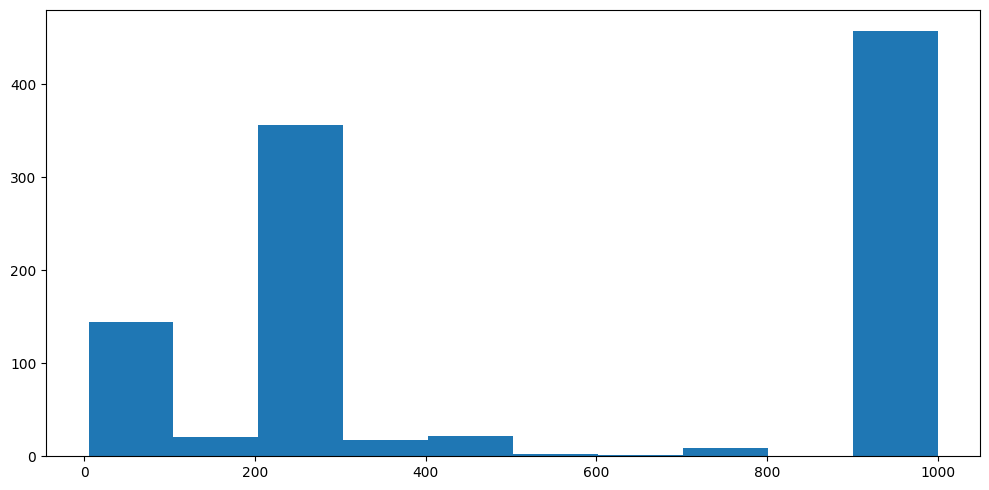

586.8950437317784
0.44412050534499514
0.034013605442176874


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(wx['erp_watts'])

plt.tight_layout()
plt.show()

print(wx['erp_watts'].mean())
print((wx['erp_watts'] == 1000).sum()/len(wx))
print((wx['erp_watts'] < 100).sum()/len(wx))


### E3 — States with the Most Transmitters

Which 10 states have the most NWR transmitters? Print the counts.

Does the ranking surprise you? What geographic or demographic factors might explain it?

AK, TX, and CA being on the list make sense because of their overall area which they consist of. It is also very southern and midwest focused which alligns with both hurricane and tornado patterns.

In [17]:
# YOUR CODE HERE
print(wx['state_province'].value_counts().head(10))

state_province
TX    77
AK    52
KY    41
MN    37
MO    35
CA    34
FL    32
MT    31
GA    30
IL    29
Name: count, dtype: int64


### E4 — Anatomy of a WFO

Pick a WFO that covers an area you know well. Filter `wx` to only that WFO's stations.

For each of its stations:
- What frequencies does it use?
- What is the range of power outputs?
- Are there any stations with known HAGL (not `default_100ft`)?

You can find the WFO code for any location at [weather.gov](https://www.weather.gov) — look for the three-letter office code (e.g., `PHI` for the Philadelphia/Mount Holly office).

In [ ]:
MY_WFO = 'PHI'  # Change this to a WFO you're interested in

# YOUR CODE HERE


### E5 — Dot Map of the Network

Plot all US NWR stations on a scatter plot (longitude vs. latitude), colored by power class:
- High: ≥ 500 W
- Mid: 100–499 W  
- Low: < 100 W

What patterns do you see geographically? Where does the network look dense vs. sparse?

In [ ]:
wx['power_class'] = np.where(
    wx['erp_watts'] < 100, 'Low',
    np.where(wx['erp_watts'] < 500, 'Mid', 'High')
)

power_styles = {
    'Low':  {'color': 'steelblue', 'size': 15},
    'Mid':  {'color': 'orange',    'size': 30},
    'High': {'color': 'red',       'size': 55},
}

fig, ax = plt.subplots(figsize=(14, 7))

for cls, style in power_styles.items():
    subset = wx[wx['power_class'] == cls]
    ax.scatter(subset['longitude'], subset['latitude'],
               c=style['color'], s=style['size'], label=cls, alpha=0.6)

ax.set_title("NWR Transmitter Network — Power Class")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Power Class")
plt.tight_layout()
plt.show()


### E6 — Interactive Map (Folium)

Build an interactive Folium map of all US NWR stations. Each marker popup should show the callsign, power in watts, city, state, and WFO.

Zoom into a few regions and note areas where stations look thinly spread. Screenshot or note the coordinates — those may be gap areas worth investigating.

In [ ]:
m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles='CartoDB positron')

# YOUR CODE HERE — add a CircleMarker for each station

display(m)


---
## Week 1 Reflection

Before moving to Week 2, write answers to these questions in the cell below. These will anchor the research going forward.

1. In plain language, what is the difference between a 5-watt and a 1,000-watt NWR transmitter in terms of who it can reach?
2. Why might terrain matter more than power output in some regions?
3. Looking at your dot map (E5), which broad regions of the US look most thinly covered? Name at least two.
4. SAME encoding allows county-level targeting. What does that mean for a resident of a county that is *technically* within 40 miles of a transmitter but separated from it by a mountain range?
5. If you were choosing a single additional metric — beyond distance to nearest transmitter — to better measure coverage quality, what would it be and why?

**Your answers:**

1.

2.

3.

4.

5.
